# Data Profiling — Spotify + Grammy Awards

Exploratory Data Analysis (EDA) over both datasets before building the ETL pipeline.

**Goals:**
- Understand the structure, data types, and quality of each source.
- Detect missing values, duplicates, and outliers.
- Identify key variables and generate statistics and plots.
- Document insights that will guide the cleaning and transformation stages.

In [29]:
# Librarys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import plotly.express as px

In [30]:
# Data Paths

data_path_spotify = Path('..') /'airflow'/ 'data' / 'spotify_dataset.csv' # identified by sp
data_path_grammys = Path('..') /'airflow'/ 'data' / 'the_grammy_awards.csv' # identified by gr

## 1. Spotify Dataset

The Spotify dataset contains ~114k rows of track-level audio features scraped from the Spotify API. Each row represents one track under one genre, so the same `track_id` can appear multiple times across different genres.

In [31]:
df_sp = pd.read_csv(data_path_spotify, low_memory=False)
df_sp.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [32]:
df_sp.tail()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.235,...,-16.393,1,0.0422,0.640,0.928,0.0863,0.0339,125.995,5,world-music
113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.117,...,-18.318,0,0.0401,0.994,0.976,0.1050,0.0350,85.239,4,world-music
113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.329,...,-10.895,0,0.0420,0.867,0.000,0.0839,0.7430,132.378,4,world-music
113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.506,...,-10.889,1,0.0297,0.381,0.000,0.2700,0.4130,135.960,4,world-music
113999,113999,2hETkH7cOfqmz3LqZDHZf5,Cesária Evora,Miss Perfumado,Barbincor,22,241826,False,0.526,0.487,...,-10.204,0,0.0725,0.681,0.000,0.0893,0.7080,79.198,4,world-music


In [33]:
print(f"Dimensiones del dataset: {df_sp.shape[0]} filas y {df_sp.shape[1]} columnas")
print("-" * 50)
df_sp.info()

Dimensiones del dataset: 114000 filas y 21 columnas
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000

In [34]:
# colummn "Unnamed: 0" adds nothing for the analysis
df_sp.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [35]:
# Null values analysis

nulls_sp = df_sp.isnull().sum()
nulls_percentage_sp = (nulls_sp / len(df_sp)) * 100
df_null_sp = pd.DataFrame({'Nulls': nulls_sp, 'Percentage (%)': nulls_percentage_sp})
print(df_null_sp)

# Show only columns with null value
display(df_null_sp[df_null_sp['Nulls'] > 0].sort_values(by='Percentage (%)', ascending=False))

                  Nulls  Percentage (%)
Unnamed: 0            0        0.000000
track_id              0        0.000000
artists               1        0.000877
album_name            1        0.000877
track_name            1        0.000877
popularity            0        0.000000
duration_ms           0        0.000000
explicit              0        0.000000
danceability          0        0.000000
energy                0        0.000000
key                   0        0.000000
loudness              0        0.000000
mode                  0        0.000000
speechiness           0        0.000000
acousticness          0        0.000000
instrumentalness      0        0.000000
liveness              0        0.000000
valence               0        0.000000
tempo                 0        0.000000
time_signature        0        0.000000
track_genre           0        0.000000


,Nulls,Percentage (%)
artists,1,0.000877
album_name,1,0.000877
track_name,1,0.000877


In [36]:
df_miss_sp = df_null_sp[df_null_sp['Percentage (%)'] > 0].sort_values(by='Percentage (%)', ascending=False)

if not df_miss_sp.empty:
    # issues with matplotlib so plotly library was used
    fig = px.bar(
        df_miss_sp,
        x='Percentage (%)',
        y=df_miss_sp.index,
        orientation='h',
        title='Data Set Spotify: Percentage of Missing Values (> 0%) by Variable',
        text='Percentage (%)' 
    )

    # customization and formating
    fig.update_traces(
        marker_color='#5b7c99', 
        texttemplate='%{text:.10f}%', 
        textposition='outside'
    )
    
    # margin and interface
    fig.update_layout(
        yaxis_title="Variables", 
        xaxis_title="% Missing",
        yaxis={'categoryorder':'total ascending'} # Ordena de mayor a menor
    )

    fig.update_xaxes(tickformat=".4f", ticksuffix="%")
    fig.show()
else:
    print("There is no Nulls Values to show")

In [37]:
total_duplicated_sp = df_sp.duplicated().sum()
print(f"{total_duplicated_sp} rows were found that were exactly the same")

if total_duplicated_sp > 0:
    # sample of some duplicated rows
    display(df_sp[df_sp.duplicated(keep=False)].sort_values(by='track_id').head(4)) 

0 rows were found that were exactly the same


In [38]:
# show only duplicates by track_id 
dup_invoices = df_sp.duplicated(subset=['track_id'], keep=False).sum()
print(f"rows with 'track_id' duplicated: {dup_invoices}")

# in this context could it be possible have duplicated by "track_id". A song
# can be pupular across diferent years

rows with 'track_id' duplicated: 40900


In [39]:
df_sp["track_genre"].unique()

<StringArray>
[   'acoustic',    'afrobeat',    'alt-rock', 'alternative',     'ambient',
       'anime', 'black-metal',   'bluegrass',       'blues',      'brazil',
 ...
     'spanish',       'study',     'swedish',   'synth-pop',       'tango',
      'techno',      'trance',    'trip-hop',     'turkish', 'world-music']
Length: 114, dtype: str

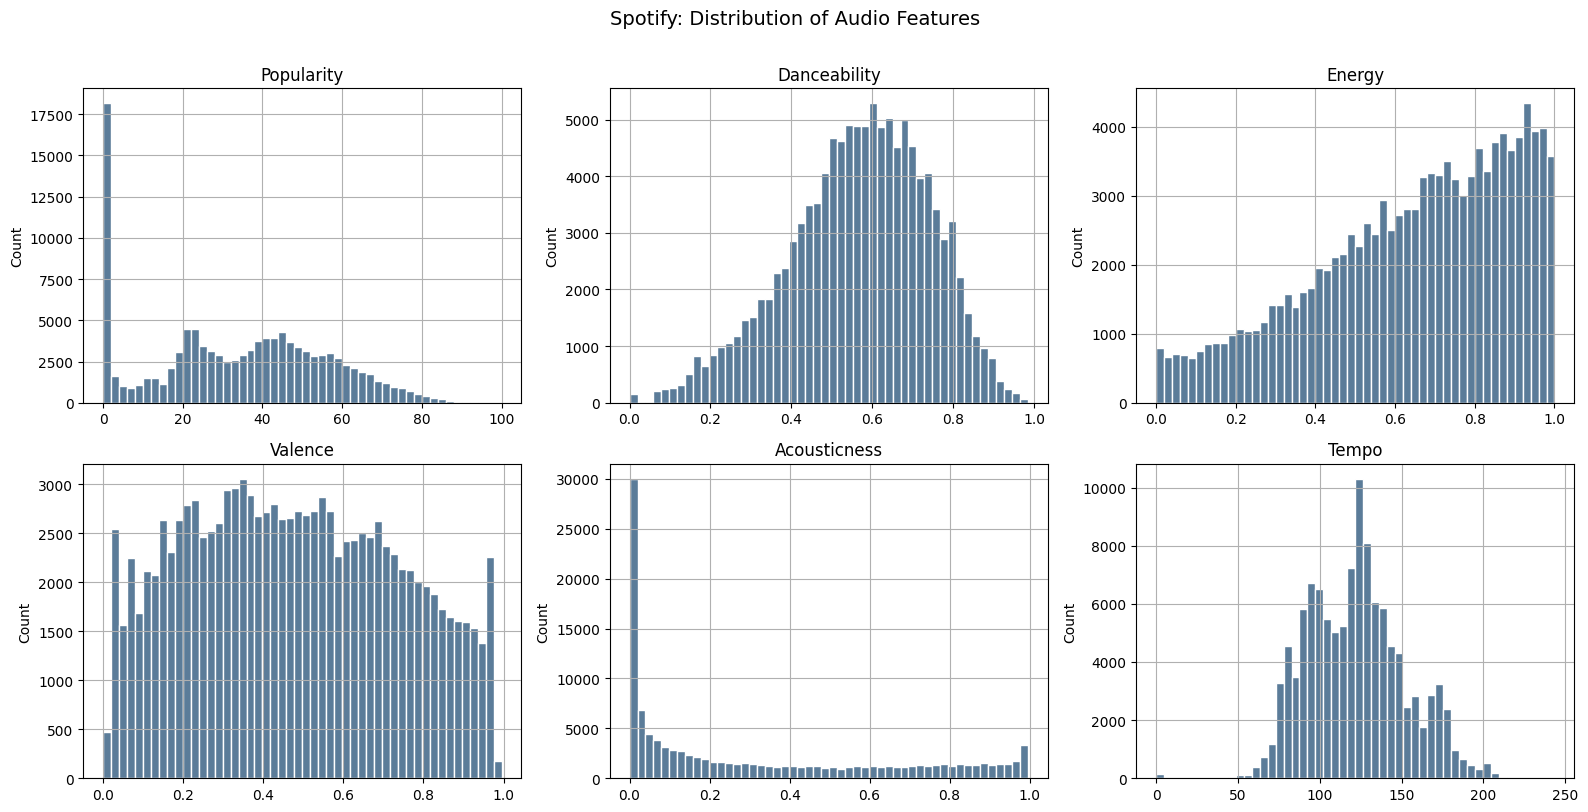

In [40]:
# Distribution of key numeric features
numeric_cols = ["popularity", "danceability", "energy", "valence", "acousticness", "tempo"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    df_sp[col].hist(bins=50, ax=ax, color="#5b7c99", edgecolor="white")
    ax.set_title(col.capitalize(), fontsize=12)
    ax.set_ylabel("Count")

fig.suptitle("Spotify: Distribution of Audio Features", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

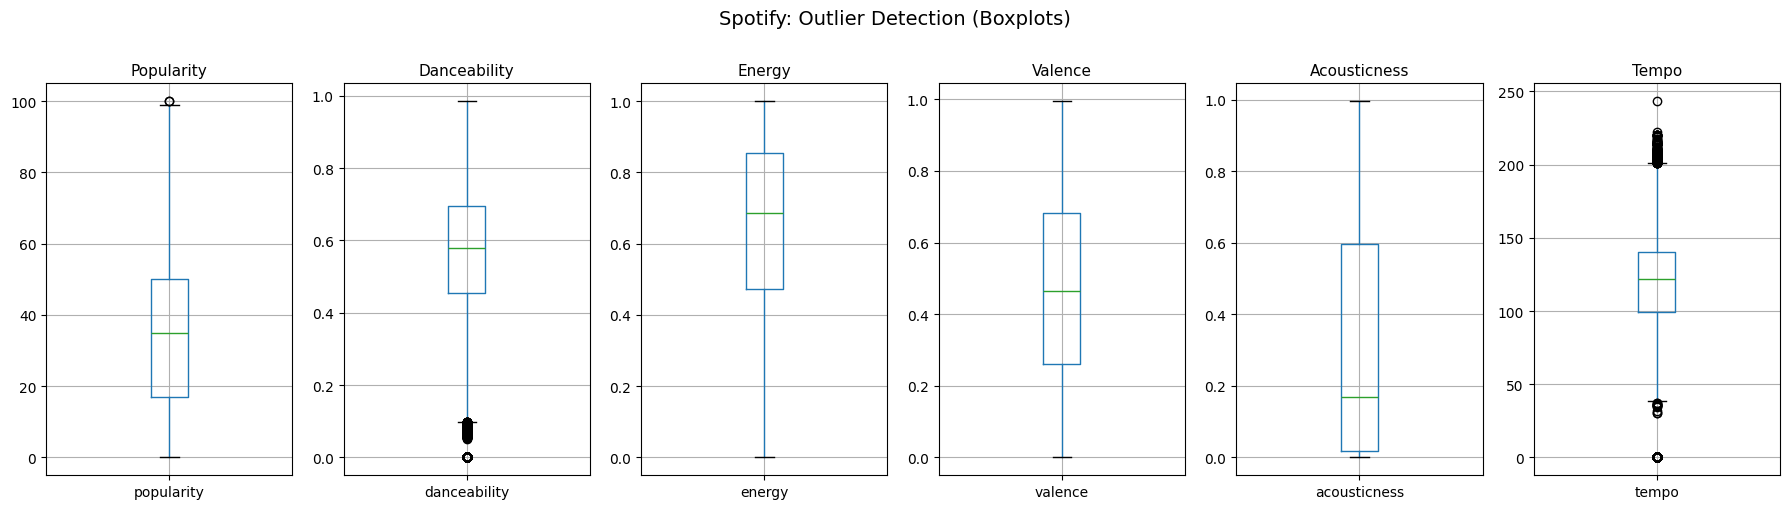

In [41]:
# Boxplots to detect outliers in numeric features
fig, axes = plt.subplots(1, 6, figsize=(18, 5))
for ax, col in zip(axes.flatten(), numeric_cols):
    df_sp.boxplot(column=col, ax=ax, vert=True)
    ax.set_title(col.capitalize(), fontsize=11)

fig.suptitle("Spotify: Outlier Detection (Boxplots)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

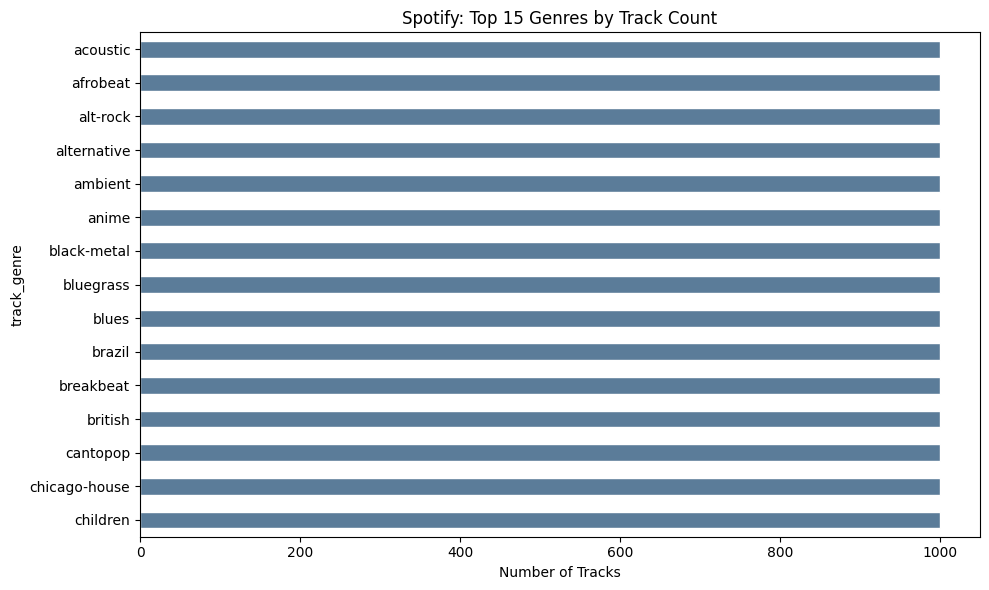

In [42]:
# Top 15 genres by track count
genre_counts = df_sp["track_genre"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
genre_counts.plot.barh(ax=ax, color="#5b7c99", edgecolor="white")
ax.set_xlabel("Number of Tracks")
ax.set_title("Spotify: Top 15 Genres by Track Count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

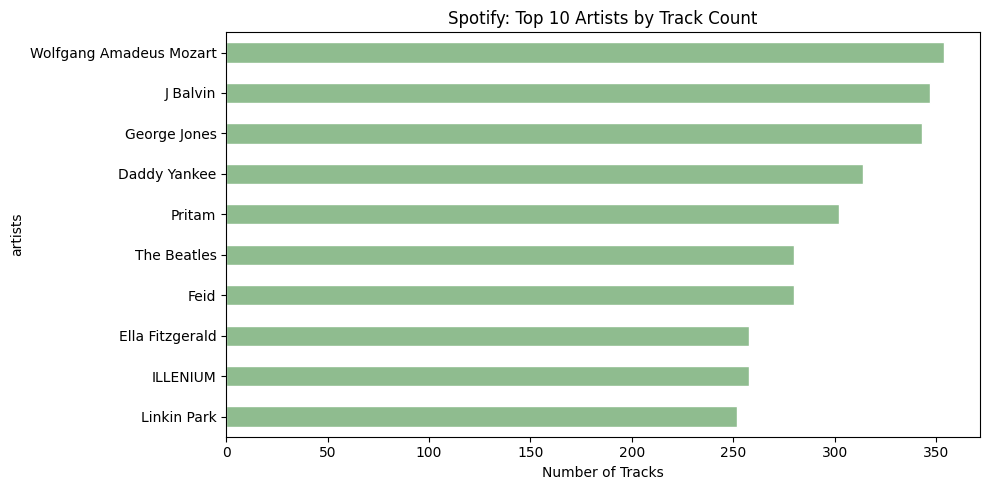

In [43]:
# Top 10 artists by number of tracks
# Artists can be separated by ";" for collaborations — we take the first one
top_artists = (
    df_sp["artists"]
    .dropna()
    .str.split(";")
    .str[0]
    .str.strip()
    .value_counts()
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 5))
top_artists.plot.barh(ax=ax, color="#8fbc8f", edgecolor="white")
ax.set_xlabel("Number of Tracks")
ax.set_title("Spotify: Top 10 Artists by Track Count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

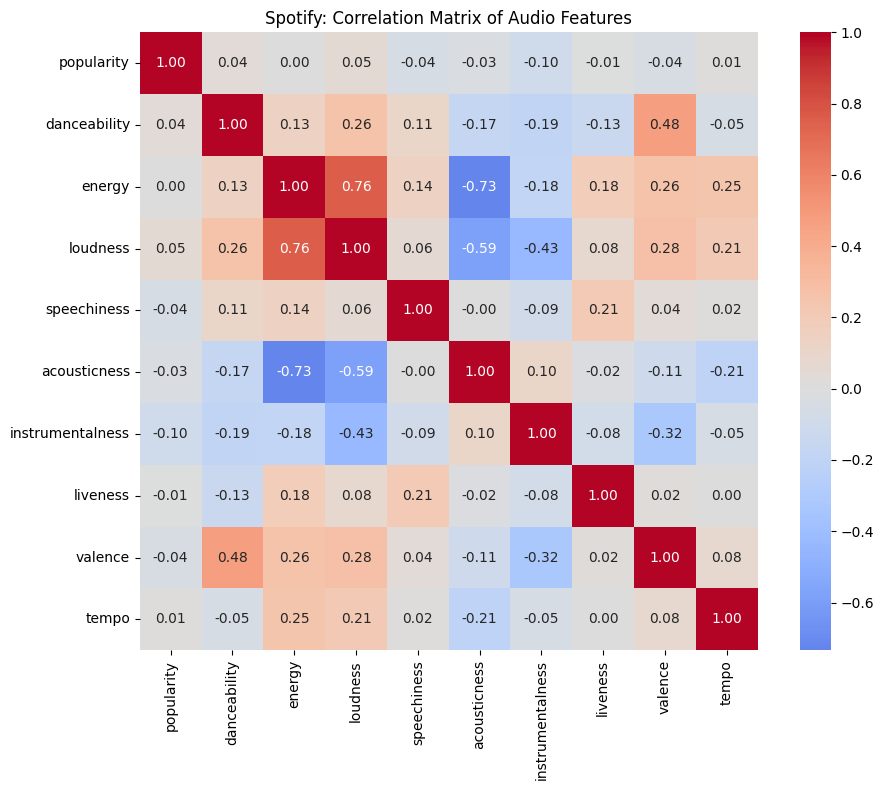

In [44]:
# Correlation heatmap of audio features
audio_features = ["popularity", "danceability", "energy", "loudness", "speechiness",
                  "acousticness", "instrumentalness", "liveness", "valence", "tempo"]

fig, ax = plt.subplots(figsize=(10, 8))
corr = df_sp[audio_features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True)
ax.set_title("Spotify: Correlation Matrix of Audio Features")
plt.tight_layout()
plt.show()

### Spotify — Key Insights for the Pipeline

1. **`Unnamed: 0` column** is just a row index from the original CSV export — it carries no information and should be dropped during extraction.
2. **Missing values** are minimal: only `artists`, `album_name`, and `track_name` have a handful of nulls. These rows cannot be matched downstream and will be dropped during cleaning.
3. **Duplicates**: `.duplicated()` reports 0 duplicates because `Unnamed: 0` makes every row technically unique. However, after dropping that column, ~450 full-row duplicates emerge. These must be removed during cleaning to avoid violating the compound primary key `(track_id, genre_key)`.
4. **`track_id` repeats across genres** — a song can appear under multiple genres (e.g., "pop" and "dance"). This is not a data quality issue but a design decision: the grain of the fact table will be `(track_id, genre_key)`, not just `track_id`.
5. **Popularity** is heavily right-skewed (most tracks have low popularity). This means averages will be pulled down and top artists will stand out significantly.
6. **Energy and loudness** are strongly positively correlated (0.76), which is expected — louder tracks tend to feel more energetic. **Energy and acousticness** are strongly negatively correlated (-0.73).
7. **114 unique genres** — the dataset is evenly distributed across genres (~1000 tracks each), suggesting it was sampled intentionally rather than scraped organically.
8. **Artist collaborations** are stored as semicolon-separated strings (e.g., `"Gen Hoshino;Foo Bar"`). For the merge with Grammys, we will normalize by keeping the first artist, lowercased and stripped.

## 2. Grammy Awards Dataset

The Grammy Awards dataset contains 4,810 records of Grammy ceremony results. In the pipeline this data is loaded into a MySQL database (`grammys_src.awards`) and then extracted via SQL. Here we profile the raw CSV to understand its structure before loading.

In [45]:
df_gr = pd.read_csv(data_path_grammys, low_memory=False)
df_gr.head()

,year,title,published_at,updated_at,category,nominee,artist,workers,img,winner
0,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,Bad Guy,Billie Eilish,"Finneas O'Connell, producer; Rob Kinelski & Fi...",https://www.grammy.com/sites/com/files/styles/...,True
1,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,"Hey, Ma",Bon Iver,"BJ Burton, Brad Cook, Chris Messina & Justin V...",https://www.grammy.com/sites/com/files/styles/...,True
2,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,7 rings,Ariana Grande,"Charles Anderson, Tommy Brown, Michael Foster ...",https://www.grammy.com/sites/com/files/styles/...,True
3,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,Hard Place,H.E.R.,"Rodney “Darkchild” Jerkins, producer; Joseph H...",https://www.grammy.com/sites/com/files/styles/...,True
4,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,Talk,Khalid,"Disclosure & Denis Kosiak, producers; Ingmar C...",https://www.grammy.com/sites/com/files/styles/...,True


In [46]:
df_gr.tail()

,year,title,published_at,updated_at,category,nominee,artist,workers,img,winner
4805,1958,1st Annual GRAMMY Awards (1958),2017-11-28T00:03:45-08:00,2019-09-10T01:11:09-07:00,Best Classical Performance - Instrumentalist (...,Tchaikovsky: Piano Concerto No. 1 In B Flat Mi...,NaN,"Van Cliburn, artist (Symphony Of The Air Orche...",NaN,True
4806,1958,1st Annual GRAMMY Awards (1958),2017-11-28T00:03:45-08:00,2019-09-10T01:11:09-07:00,Best Classical Performance - Instrumentalist (...,Segovia Golden Jubilee,NaN,"Andres Segovia, artist",https://www.grammy.com/sites/com/files/styles/...,True
4807,1958,1st Annual GRAMMY Awards (1958),2017-11-28T00:03:45-08:00,2019-09-10T01:11:09-07:00,Best Classical Performance - Chamber Music (In...,Beethoven: Quartet 130,NaN,"Hollywood String Quartet (Alvin Dinkin, Paul S...",NaN,True
4808,1958,1st Annual GRAMMY Awards (1958),2017-11-28T00:03:45-08:00,2019-09-10T01:11:09-07:00,Best Classical Performance - Vocal Soloist (Wi...,Operatic Recital,NaN,NaN,NaN,True
4809,1958,1st Annual GRAMMY Awards (1958),2017-11-28T00:03:45-08:00,2019-09-10T01:11:09-07:00,Best Classical Performance - Operatic Or Choral,Virtuoso,NaN,"Roger Wagner, choir director",NaN,True


In [47]:
print(f"Dimensiones del dataset: {df_gr.shape[0]} filas y {df_gr.shape[1]} columnas")
print("-" * 50)
df_gr.info() # date format and null values issues detected

Dimensiones del dataset: 4810 filas y 10 columnas
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 4810 entries, 0 to 4809
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   year          4810 non-null   int64
 1   title         4810 non-null   str  
 2   published_at  4810 non-null   str  
 3   updated_at    4810 non-null   str  
 4   category      4810 non-null   str  
 5   nominee       4804 non-null   str  
 6   artist        2970 non-null   str  
 7   workers       2620 non-null   str  
 8   img           3443 non-null   str  
 9   winner        4810 non-null   bool 
dtypes: bool(1), int64(1), str(8)
memory usage: 343.0 KB


In [48]:
# Null values analysis

nulls_gr = df_gr.isnull().sum()
nulls_percentage_gr = (nulls_gr / len(df_gr)) * 100
df_null_gr = pd.DataFrame({'Nulls': nulls_gr, 'Percentage (%)': nulls_percentage_gr})
print(df_null_gr)

# Show only columns with null value
display(df_null_gr[df_null_gr['Nulls'] > 0].sort_values(by='Percentage (%)', ascending=False))

              Nulls  Percentage (%)
year              0        0.000000
title             0        0.000000
published_at      0        0.000000
updated_at        0        0.000000
category          0        0.000000
nominee           6        0.124740
artist         1840       38.253638
workers        2190       45.530146
img            1367       28.419958
winner            0        0.000000


,Nulls,Percentage (%)
workers,2190,45.530146
artist,1840,38.253638
img,1367,28.419958
nominee,6,0.124740


In [49]:
df_miss_gr = df_null_gr[df_null_gr['Percentage (%)'] > 0].sort_values(by='Percentage (%)', ascending=False)

if not df_miss_gr.empty:
    # issues with matplotlib so plotly library was used
    fig = px.bar(
        df_miss_gr,
        x='Percentage (%)',
        y=df_miss_gr.index,
        orientation='h',
        title='Data Set Grammys: Percentage of Missing Values (> 0%) by Variable',
        text='Percentage (%)' 
    )

    # customization and formating
    fig.update_traces(
        marker_color='#5b7c99', 
        texttemplate='%{text:.10f}%', 
        textposition='outside'
    )
    
    # margin and interface
    fig.update_layout(
        yaxis_title="Variables", 
        xaxis_title="% Missing",
        yaxis={'categoryorder':'total ascending'} # Ordena de mayor a menor
    )

    fig.update_xaxes(ticksuffix="%")
    fig.show()
else:
    print("There is no Nulls Values to show")

In [50]:
total_duplicated_gr = df_gr.duplicated().sum()
print(f"{total_duplicated_gr} rows were found that were exactly the same")

if total_duplicated_gr > 0:
    # sample of some duplicated rows
    display(df_gr[df_gr.duplicated(keep=False)].sort_values(by='year').head(4)) 

0 rows were found that were exactly the same


In [51]:
df_gr["category"].unique() # across the years the categories could change, conclusion: no issues for now

<StringArray>
[                                                                    'Record Of The Year',
                                                                      'Album Of The Year',
                                                                       'Song Of The Year',
                                                                        'Best New Artist',
                                                              'Best Pop Solo Performance',
                                                         'Best Pop Duo/Group Performance',
                                                       'Best Traditional Pop Vocal Album',
                                                                   'Best Pop Vocal Album',
                                                                   'Best Dance Recording',
                                                            'Best Dance/Electronic Album',
 ...
                                                           'Best Jazz P

In [52]:
df_gr["title"].unique() # must be only 62, no issues

<StringArray>
['62nd Annual GRAMMY Awards  (2019)', '61st Annual GRAMMY Awards  (2018)',
 '60th Annual GRAMMY Awards  (2017)', '59th Annual GRAMMY Awards  (2016)',
 '58th Annual GRAMMY Awards  (2015)', '57th Annual GRAMMY Awards  (2014)',
 '56th Annual GRAMMY Awards  (2013)', '55th Annual GRAMMY Awards  (2012)',
 '54th Annual GRAMMY Awards  (2011)', '53rd Annual GRAMMY Awards  (2010)',
 '52nd Annual GRAMMY Awards  (2009)', '51st Annual GRAMMY Awards  (2008)',
 '50th Annual GRAMMY Awards  (2007)', '49th Annual GRAMMY Awards  (2006)',
 '48th Annual GRAMMY Awards  (2005)', '47th Annual GRAMMY Awards  (2004)',
 '46th Annual GRAMMY Awards  (2003)', '45th Annual GRAMMY Awards  (2002)',
 '44th Annual GRAMMY Awards  (2001)', '43rd Annual GRAMMY Awards  (2000)',
 '42nd Annual GRAMMY Awards  (1999)', '41st Annual GRAMMY Awards  (1998)',
 '40th Annual GRAMMY Awards  (1997)', '39th Annual GRAMMY Awards  (1996)',
 '38th Annual GRAMMY Awards  (1995)', '37th Annual GRAMMY Awards  (1994)',
 '36th Annu

In [53]:
df_gr["winner"].unique() # Only winners in the grammy's df

array([ True])

In [54]:
df_gr.describe(include="all")

,year,title,published_at,updated_at,category,nominee,artist,workers,img,winner
count,4810.000000,4810,4810,4810,4810,4804,2970,2620,3443,4810
unique,NaN,62,4,10,638,4131,1658,2366,1463,1
top,NaN,62nd Annual GRAMMY Awards (2019),2017-11-28T00:03:45-08:00,2019-09-10T01:08:19-07:00,Song Of The Year,Steven Epstein,(Various Artists),"John Williams, composer (John Williams)",https://www.grammy.com/sites/com/files/styles/...,True
freq,NaN,433,4205,778,70,7,66,20,26,4810
mean,1995.566944,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,17.149720,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1958.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1983.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1998.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


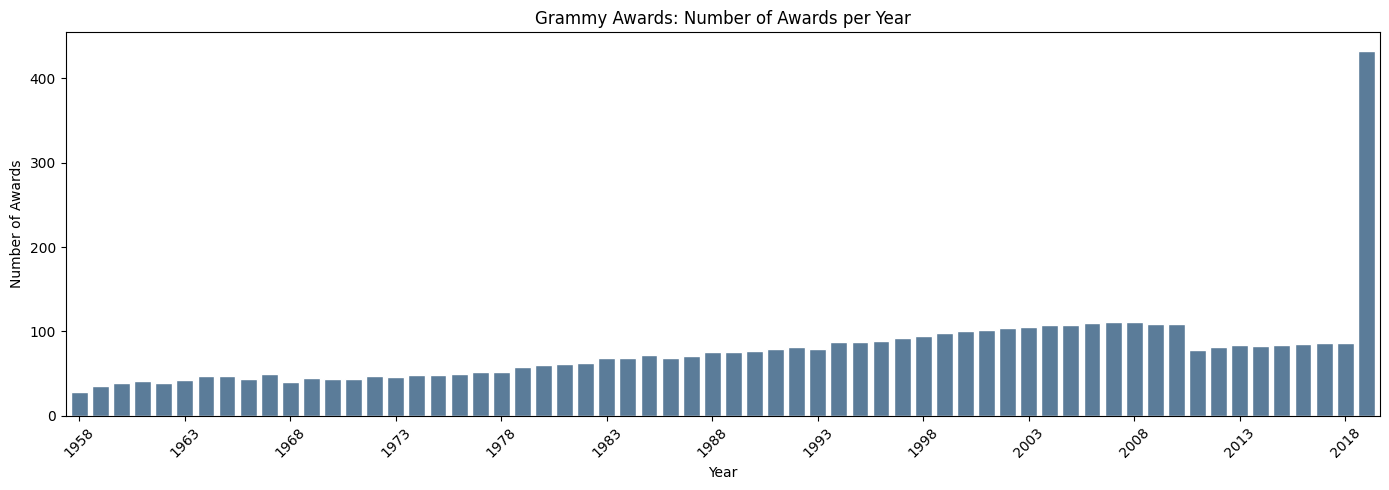

In [55]:
# Distribution of Grammy ceremonies over the years
fig, ax = plt.subplots(figsize=(14, 5))
df_gr["year"].value_counts().sort_index().plot(kind="bar", ax=ax, color="#5b7c99", edgecolor="white", width=0.8)
ax.set_xlabel("Year")
ax.set_ylabel("Number of Awards")
ax.set_title("Grammy Awards: Number of Awards per Year")
# Show only every 5th year label to avoid clutter
ticks = ax.get_xticks()
labels = [t.get_text() for t in ax.get_xticklabels()]
ax.set_xticks(ticks[::5])
ax.set_xticklabels(labels[::5], rotation=45)
plt.tight_layout()
plt.show()

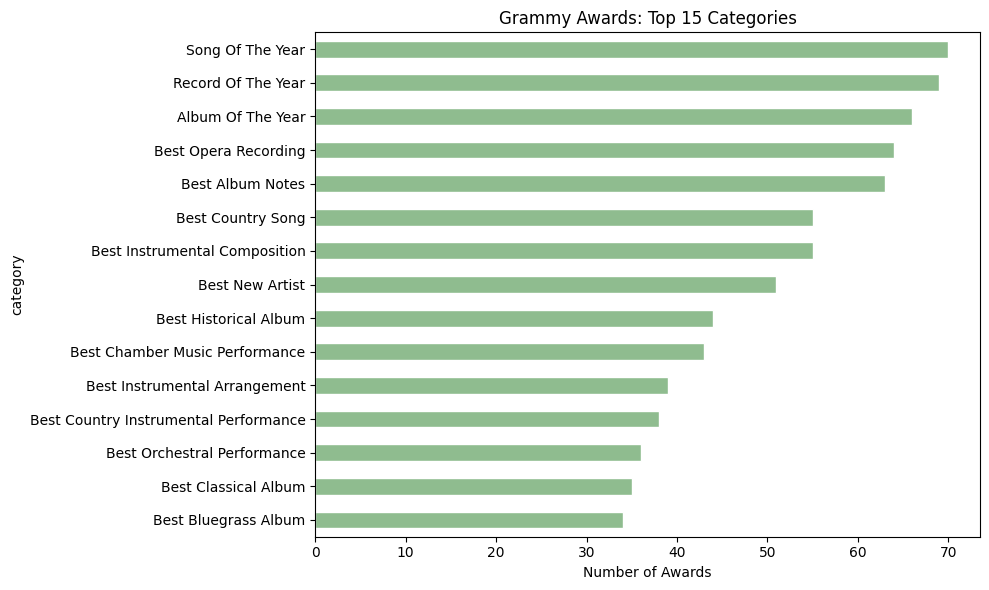

In [56]:
# Top 15 Grammy categories by frequency
top_categories = df_gr["category"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top_categories.plot.barh(ax=ax, color="#8fbc8f", edgecolor="white")
ax.set_xlabel("Number of Awards")
ax.set_title("Grammy Awards: Top 15 Categories")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

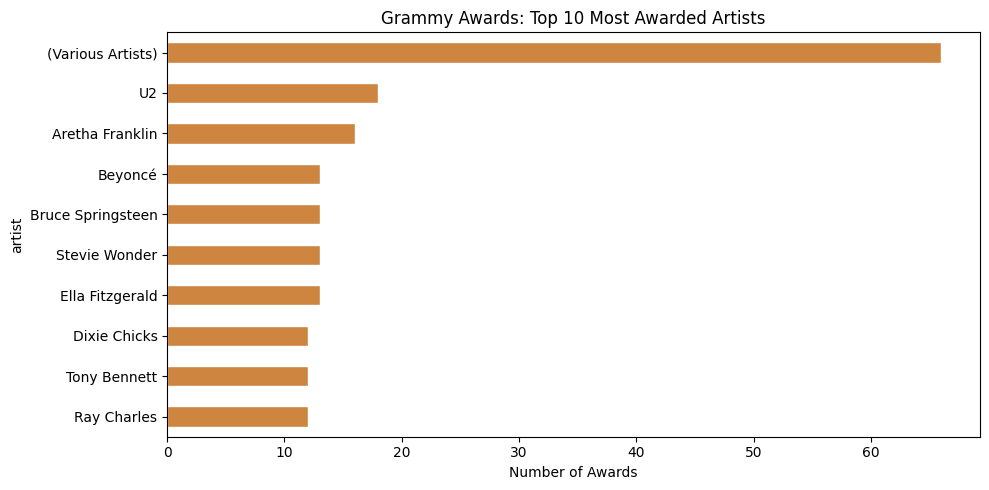

In [57]:
# Top 10 most awarded artists
top_grammy_artists = df_gr["artist"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
top_grammy_artists.plot.barh(ax=ax, color="#cd853f", edgecolor="white")
ax.set_xlabel("Number of Awards")
ax.set_title("Grammy Awards: Top 10 Most Awarded Artists")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Grammy Awards — Key Insights for the Pipeline

1. **All rows have `winner = True`**: the dataset only contains winners, not nominees. This means `grammy_wins` and `grammy_nominations` will be equal in the merge. KPIs that depend on the winner/nominee distinction need a different data source.
2. **Missing values**: `artist` has ~2.5% nulls and `nominee` has a small number. During cleaning, null artists will be filled with `"unknown"` and excluded from the merge key aggregation so they don't pollute the Spotify join.
3. **No full-row duplicates** — the dataset is clean in that regard.
4. **`workers` and `img` columns** carry no analytical value (free-text credit lists and thumbnail URLs). They will be dropped during cleaning.
5. **`published_at` and `updated_at`** mix naive and timezone-aware datetime strings. The cleaning stage must force `utc=True` when parsing to avoid a `ValueError: Mixed timezones detected`.
6. **The number of categories has grown** across decades (more specialized awards in recent years). This is not a data quality issue — it reflects the evolution of the ceremony.
7. **Text columns loaded via `LOAD DATA INFILE`** into MySQL will store empty CSV fields as empty strings (`""`) instead of `NULL`. The cleaning stage must convert these back to `NA` before any null-dependent logic runs.
8. **The join key** between Spotify and Grammys will be `artist_norm` — the first artist name, lowercased and stripped. This is a best-effort match; fuzzy matching is out of scope.

## 3. Summary — Profiling Decisions that Guide the ETL

| Decision | Source | Rationale |
|----------|--------|-----------|
| Drop `Unnamed: 0` on extraction | Spotify | Artificial index that hides ~450 true duplicates |
| Drop full-row duplicates after removing index | Spotify | Would break compound PK `(track_id, genre_key)` |
| Keep `track_id` duplicates across genres | Spotify | Legitimate: same track appears under multiple genres |
| Drop rows with null `artists`/`album_name`/`track_name` | Spotify | Cannot be matched or modeled downstream |
| Normalize artist to first name, lowercased, stripped | Both | Best-effort join key; semicolon-separated collaborations |
| Fill null `artist` with `"unknown"`, exclude from merge | Grammys | Prevents polluting aggregation buckets |
| Force `utc=True` on datetime parsing | Grammys | Avoids mixed-timezone ValueError |
| Convert `""` → `NA` on text columns after DB load | Grammys | MySQL `LOAD DATA` stores blanks as empty strings, not NULL |
| Drop `workers` and `img` columns | Grammys | No analytical value |
| Use star schema with compound grain `(track_id, genre_key)` | Both | Preserves the genre dimension without collapsing tracks |